In [61]:
import pandas as pd
import yfinance as yf
import numpy as np
import ta
import warnings
warnings.filterwarnings('ignore')

In [62]:
# take 5 Indian stocks
stocks = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS']
data = yf.download(stocks, start='2015-01-01', end='2019-12-31')

[*********************100%***********************]  4 of 4 completed


In [63]:
def add_indicators(data, stocks):
    for stock in stocks:
        # RSI
        data[('RSI', stock)] = ta.momentum.RSIIndicator(data[('Close', stock)], window=14).rsi()
        # MACD
        data[('MACD', stock)] = ta.trend.macd(data[('Close', stock)])
        # EMA
        data[('EMA', stock)] = ta.trend.ema_indicator(data[('Close', stock)], window=14)
        # SMA
        data[('SMA', stock)] = ta.trend.sma_indicator(data[('Close', stock)], window=14)
        # ADXR
        data[('ADXR', stock)] = ta.trend.ADXIndicator(data[('High', stock)], data[('Low', stock)], data[('Close', stock)], window=14).adx()
        # ATR
        data[('ATR', stock)] = ta.volatility.AverageTrueRange(data[('High', stock)], data[('Low', stock)], data[('Close', stock)], window=14).average_true_range()


In [8]:
# drop NaN values
add_indicators(data, stocks)
data.dropna(inplace=True)
data.head(2)

Price                       Adj Close                                       \
Ticker                    HDFCBANK.NS     INFY.NS RELIANCE.NS       TCS.NS   
Date                                                                         
2015-03-17 00:00:00+00:00  489.370697  434.687378  176.924194  1087.951538   
2015-03-18 00:00:00+00:00  491.914612  432.553192  179.360718  1077.697998   

Price                           Close                                    \
Ticker                    HDFCBANK.NS  INFY.NS RELIANCE.NS       TCS.NS   
Date                                                                      
2015-03-17 00:00:00+00:00  529.025024  560.125  195.861496  1291.849976   
2015-03-18 00:00:00+00:00  531.775024  557.375  198.558777  1279.675049   

Price                            High              ...         EMA  \
Ticker                    HDFCBANK.NS     INFY.NS  ... HDFCBANK.NS   
Date                                               ...               
2015-03-17 00:00:00+00:00  532.950012  569.875000  ...  529.329585   
2015-03-18 00:00:00+00:00  535.950012  565.712524  ...  529.655644   

Price                             SMA        ADXR         ATR        RSI  \
Ticker                    HDFCBANK.NS HDFCBANK.NS HDFCBANK.NS    INFY.NS   
Date                                                                       
2015-03-17 00:00:00+00:00  529.848219         0.0   11.477732  48.561444   
2015-03-18 00:00:00+00:00  530.244651         0.0   11.325754  46.716639   

Price                          MACD         EMA         SMA    ADXR        ATR  
Ticker                      INFY.NS     INFY.NS     INFY.NS INFY.NS    INFY.NS  
Date                                                                            
2015-03-17 00:00:00+00:00 -2.012714  560.589661  561.952680     0.0  13.426914  
2015-03-18 00:00:00+00:00 -2.079196  560.161040  560.379464     0.0  13.187493  

[2 rows x 48 columns]

In [9]:
features = ['RSI', 'MACD', 'EMA', 'SMA', 'ADXR', 'ATR']
data.xs("RELIANCE.NS", axis=1, level=1)[features][:2]

Price,RSI,MACD,EMA,SMA,ADXR,ATR
Date,,,,,,
2015-03-17 00:00:00+00:00,43.189259,-2.547972,197.456918,197.171767,0.0,5.005039
2015-03-18 00:00:00+00:00,48.097151,-2.238762,197.603833,197.588115,0.0,4.934082


In [37]:
train = data.loc['2015-01-01':'2018-06-30']
val = data.loc['2018-07-01':'2018-12-31']
test = data.loc['2019-01-01':'2019-12-31']


# scale and retain the datframe
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

train_scaled = pd.DataFrame(train_scaled, columns=data.columns)
val_scaled = pd.DataFrame(val_scaled, columns=data.columns)
test_scaled = pd.DataFrame(test_scaled, columns=data.columns)

In [ ]:
test_scaled.head(2)

Price    Adj Close                                       Close            \
Ticker HDFCBANK.NS   INFY.NS RELIANCE.NS    TCS.NS HDFCBANK.NS   INFY.NS   
0         0.086520  0.388866    0.034233  0.232690    0.096424  0.569041   
1         0.090914  0.377686    0.042995  0.219041    0.101019  0.556362   

Price                               High            ...         EMA  \
Ticker RELIANCE.NS    TCS.NS HDFCBANK.NS   INFY.NS  ... HDFCBANK.NS   
0         0.036787  0.298820    0.090335  0.589963  ...    0.072153   
1         0.046204  0.283742    0.095323  0.570484  ...    0.072746   

Price          SMA        ADXR         ATR       RSI      MACD       EMA  \
Ticker HDFCBANK.NS HDFCBANK.NS HDFCBANK.NS   INFY.NS   INFY.NS   INFY.NS   
0         0.079721         0.0    0.312858  0.431997  0.401243  0.602055   
1         0.080446         0.0    0.302205  0.402213  0.399589  0.599713   

Price        SMA    ADXR       ATR  
Ticker   INFY.NS INFY.NS   INFY.NS  
0       0.615494     0.0  0.498155  
1       0.606953     0.0  0.481234  

[2 rows x 48 columns]

In [33]:
def prepare_lstm_data(data, ticker ,features, lookback=30):
    X, y = [], []
    stock_data = data.xs(ticker, axis=1, level=1)[features]

    for i in range(len(stock_data) - lookback - 3): # Predict next 3 days
        X.append(stock_data.iloc[i : i + lookback].values)
        y.append(stock_data.iloc[i + lookback:i + lookback + 3].values)
    
    return np.array(X), np.array(y).reshape(-1, len(features) * 3)


# Select features for prediction
# features = ["RSI", "MACD", "SMA", "EMA", "ADXR", "ATR"]
X_train, y_train = prepare_lstm_data(train_scaled, stocks[0], features)
X_val, y_val = prepare_lstm_data(val_scaled, stocks[0], features)
X_test, y_test = prepare_lstm_data(test_scaled, stocks[0], features)


In [34]:
# shape of X_train and y_train
X_train.shape, y_train.shape

((781, 30, 6), (781, 18))

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(30, 6)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(6*3)  # 7 indicators * 3 days
])


In [38]:
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1)


Epoch 1/50

25/25 [==============================] - 14s 135ms/step - loss: 0.0985 - val_loss: 0.2877
Epoch 2/50
25/25 [==============================] - 1s 44ms/step - loss: 0.0366 - val_loss: 0.2435
Epoch 3/50
25/25 [==============================] - 1s 46ms/step - loss: 0.0293 - val_loss: 0.2328
Epoch 4/50
25/25 [==============================] - 1s 47ms/step - loss: 0.0275 - val_loss: 0.2173
Epoch 5/50
25/25 [==============================] - 1s 49ms/step - loss: 0.0237 - val_loss: 0.2360
Epoch 6/50
25/25 [==============================] - 1s 46ms/step - loss: 0.0223 - val_loss: 0.2222
Epoch 7/50
25/25 [==============================] - 1s 47ms/step - loss: 0.0209 - val_loss: 0.2021
Epoch 8/50
25/25 [==============================] - 1s 51ms/step - loss: 0.0212 - val_loss: 0.2047
Epoch 9/50
25/25 [==============================] - 2s 61ms/step - loss: 0.0189 - val_loss: 0.2064
Epoch 10/50
25/25 [==============================] - 1s 49ms/step - loss: 0.0177 - val_loss: 0.1999
Epoch

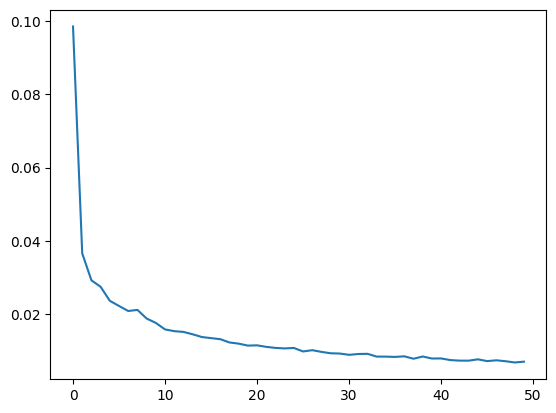

In [39]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss']) 

In [ ]:
def prepare_svr_data(data, ticker ,features):
    X, y = [], []
    stock_data = data.xs(ticker, axis=1, level=1)[features]
    stock_prices = data.xs(ticker, axis=1, level=1)['Adj Close']

    for i in range(len(stock_data) - 3): # Predict next 3 days
        X.append(stock_data.iloc[i])    # (sample, 3 * features)
        y.append(stock_prices.iloc[i])  # (sample, 3)
    
    return np.array(X), np.array(y)

def train_svr(X_train, y_train):
    from sklearn.svm import SVR
    from sklearn.model_selection import GridSearchCV

    svr = SVR()
    parameters = {'kernel': ['rbf'], 'C': [1, 10, 100], 'gamma': [0.1, 0.01]}
    clf = GridSearchCV(svr, parameters)
    clf.fit(X_train, y_train)

    return clf

In [ ]:
# features = ["RSI", "MACD", "SMA", "EMA", "ADXR", "ATR"]
X_train_svr, y_train_svr = prepare_svr_data(train_scaled, stocks[0], features)
X_val_svr, y_val_svr = prepare_svr_data(val_scaled, stocks[0], features)
X_test_svr, y_test_svr = prepare_svr_data(test_scaled, stocks[0], features)

In [56]:
X_train_svr.shape, y_train_svr.shape

((811, 6), (811,))

In [60]:
# Train the SVR model
model_svr = train_svr(X_train_svr, y_train_svr)

# MSE on test data
from sklearn.metrics import mean_squared_error
y_pred = model_svr.predict(X_test_svr)
mean_squared_error(y_test_svr, y_pred)


0.035510487567328004

In [ ]:
# After training the model, we can use it to predict the stock prices for the next 3 days.

# LSTM output shape -> (samples, 3 * features) -> 

In [34]:
#  Cycle
#  Momentum
#  Trend
#  Trend
#  Trend
#  Trend
#  Volatilit

# def applyIndicator():




rsi_multi_index = pd.MultiIndex.from_product([['RSI'], stocks], names=['Indicator', 'Stock'])
rsi_df = pd.DataFrame(index=data.index, columns=rsi_multi_index)
for stock in stocks:
    rsi_df['RSI'][stock] = ta.momentum.RSIIndicator(data['Close'][stock], window = 14).rsi()
rsi_df.head()

Indicator                         RSI                           
Stock                     RELIANCE.NS TCS.NS HDFCBANK.NS INFY.NS
Date                                                            
2020-01-01 00:00:00+00:00         NaN    NaN         NaN     NaN
2020-01-02 00:00:00+00:00         NaN    NaN         NaN     NaN
2020-01-03 00:00:00+00:00         NaN    NaN         NaN     NaN
2020-01-06 00:00:00+00:00         NaN    NaN         NaN     NaN
2020-01-07 00:00:00+00:00         NaN    NaN         NaN     NaN

In [43]:
# data['Close'][stocks[0]]
rsi_df['RSI'][stocks[0]] = 0.0

In [44]:
rsi_df['RSI'][stocks[0]]

Date
2020-01-01 00:00:00+00:00    NaN
2020-01-02 00:00:00+00:00    NaN
2020-01-03 00:00:00+00:00    NaN
2020-01-06 00:00:00+00:00    NaN
2020-01-07 00:00:00+00:00    NaN
                            ... 
2020-12-23 00:00:00+00:00    NaN
2020-12-24 00:00:00+00:00    NaN
2020-12-28 00:00:00+00:00    NaN
2020-12-29 00:00:00+00:00    NaN
2020-12-30 00:00:00+00:00    NaN
Name: RELIANCE.NS, Length: 250, dtype: object

In [40]:
 ta.momentum.RSIIndicator(data['Close'][stocks[0]], window = 14).rsi()

Date
2020-01-01 00:00:00+00:00          NaN
2020-01-02 00:00:00+00:00          NaN
2020-01-03 00:00:00+00:00          NaN
2020-01-06 00:00:00+00:00          NaN
2020-01-07 00:00:00+00:00          NaN
                               ...    
2020-12-23 00:00:00+00:00    42.572110
2020-12-24 00:00:00+00:00    52.147584
2020-12-28 00:00:00+00:00    53.661212
2020-12-29 00:00:00+00:00    51.138636
2020-12-30 00:00:00+00:00    52.135322
Name: rsi, Length: 250, dtype: float64